IMPORTING THE DATASET FROM KAGGLE

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

Now that we have download our data from kaggle through the kagglehub API we are now going to explore the data and preprocess it before starting the process of training the our classifier model.

EXPLORE IMAGE DATASET FOR NORMAL SUBJECTS.

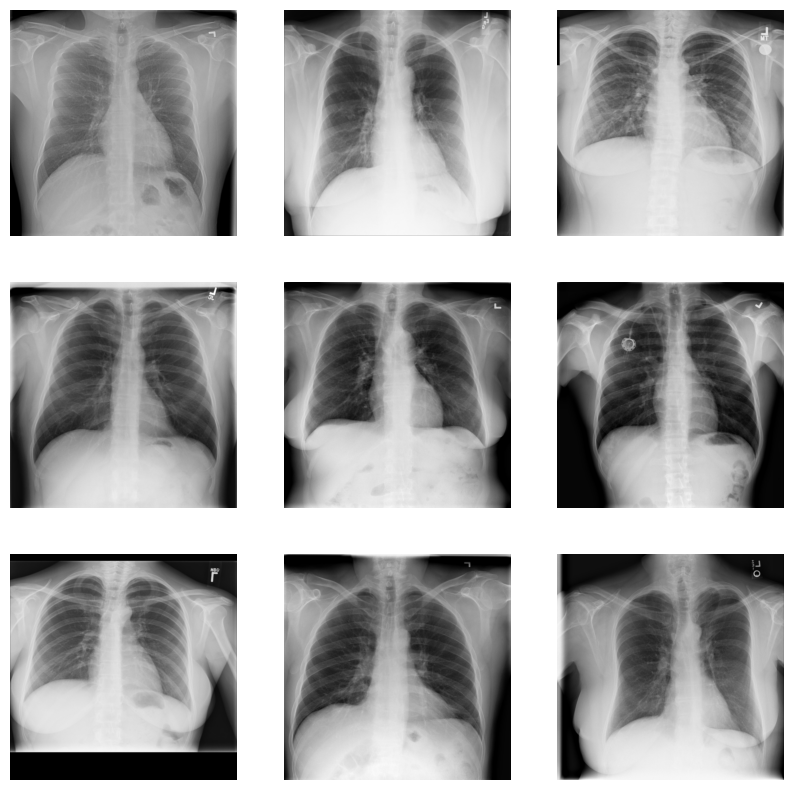

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

folder_Normal = "/home/izy/.cache/kagglehub/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset/versions/3/Normal"

files = os.listdir(folder_Normal)[:9]

plt.figure(figsize=(10,10))

for i, file in enumerate(files):
    img = Image.open(os.path.join(folder_Normal, file))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

IMAGE DATASET FOR THE TB-PATIENTS

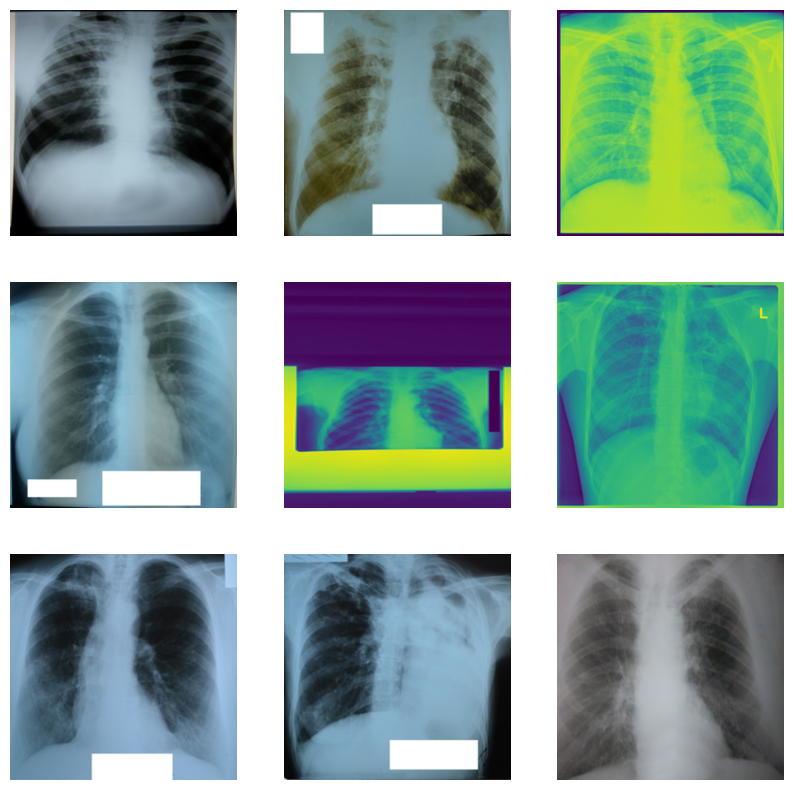

In [ ]:
folder_TB = "/home/izy/.cache/kagglehub/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset/versions/3/Tuberculosis"
files = os.listdir(folder_TB)[:9]

plt.figure(figsize=(10,10))

for i, file in enumerate(files):
    img = Image.open(os.path.join(folder_TB, file))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

DATASET CLEANING AND IMAGE RESIZE

In [ ]:
Normal = os.listdir(folder_Normal)
TB = os.listdir(folder_TB)
print("Number of dataset in each class[Normal , Tuberculosis]: ")
print("Normal", Normal.__len__())
print("Tuberculosis", TB.__len__())

Number of dataset in each class[Normal , Tuberculosis]: 
Normal 3500
Tuberculosis 700


Image size:

In [ ]:
folder_Normal = "/home/izy/.cache/kagglehub/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset/versions/3/Normal"

files = os.listdir(folder_Normal)
for i in files:
    path = os.path.join(folder_Normal, i)

    x = Image.open(path)
    print(x.size)

(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)

In [ ]:
files = os.listdir(folder_TB)
for x in files:
    path = os.path.join(folder_TB, x)
    y = Image.open(path)
    print(y.size)

(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)

Observation: Both the image datasets from Normal and Tuberculosis have a uniform imagesize of 512 x 512

SPLITTING THE DATA INTO TRAINING, TESTING AND VALIDATION SET.

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
  
base_dir ="/home/izy/.cache/kagglehub/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset/versions/3"

img_size = (224, 224)
seed = 123

train_ds = image_dataset_from_directory(
    base_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=['Normal', 'Tuberculosis'],
    batch_size=32,
    image_size=img_size,
    shuffle=True,
    seed=seed,
    validation_split=0.2,
    subset='training',
    verbose=True
)


val_ds = image_dataset_from_directory(
    base_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=['Normal', 'Tuberculosis'],
    batch_size=32,
    image_size=img_size,
    shuffle=True,
    seed=seed,
    validation_split=0.2,
    subset='validation',
    verbose=True
)

val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds  = val_ds.skip(val_batches // 2)

Found 4200 files belonging to 2 classes.
Using 3360 files for training.
Found 4200 files belonging to 2 classes.
Using 840 files for validation.


BUILDING A CNN MODEL

In [11]:
from tensorflow.keras import layers, models, Sequential, Input
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(224,224,3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])

COMPILE THE MODEL

In [18]:
# Compile the model to prepare it for training
model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)

MODEL TRAINING

In [19]:
history = model.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
)

Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 444ms/step - accuracy: 0.7929 - loss: 1.3281 - val_accuracy: 0.8986 - val_loss: 0.3440
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 498ms/step - accuracy: 0.8884 - loss: 0.3459 - val_accuracy: 0.9057 - val_loss: 0.2445
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 497ms/step - accuracy: 0.8979 - loss: 0.2959 - val_accuracy: 0.8962 - val_loss: 0.2985
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 491ms/step - accuracy: 0.9155 - loss: 0.2556 - val_accuracy: 0.9009 - val_loss: 0.2139
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 494ms/step - accuracy: 0.9152 - loss: 0.2229 - val_accuracy: 0.9033 - val_loss: 0.2076
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 494ms/step - accuracy: 0.9185 - loss: 0.2073 - val_accuracy: 0.9009 - val_loss: 0.1863
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 490ms/step - accuracy: 0.9196 - loss: 0.2016 - val_accuracy: 0.8962 - val_loss: 0.2771
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 492ms/step - accuracy: 0.9304 -

MODEL EVALUATION

UNDER DEVELOPMENT

In [ ]:
from tensorflow.keras import layers, models, Sequential, Input
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(2, activation='softmax'))

# Compile the model to prepare it for training
model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ global_average_pooling2d_6      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)